# Attitude Types Across German Originals, English Originals, and German Translations

This notebook compares how **Attitude types** (Appreciation, Judgement, Affect) are
expressed for six adjective concepts, across **three sources**:

| Concept | German original | English original | German translation |
|---|---|---|---|
| 1 | gut | good | gut |
| 2 | wichtig | important | wichtig |
| 3 | glücklich | happy | glücklich |
| 4 | richtig | right | richtig |
| 5 | falsch | wrong | falsch |
| 6 | schlecht | bad | schlecht |

- **German original**: the adjective as used by German-speaking TED talk speakers
  (Bianca's `..._orig_Bianca.xlsx` annotations).
- **English original / German translation**: the English adjective as used by
  English-speaking TED talk speakers, aligned with how it was actually translated into
  German (Bianca's `..._Bianca.xlsx` files, e.g. `bad_Bianca.xlsx`). Since a translator
  doesn't always pick the "expected" German word (e.g. *bad* might become *schlecht*,
  *schlimm*, *übel*, ...), **we only keep translation instances where the German
  translation actually contains the target German adjective** (e.g. only keep rows
  where *bad* was translated using *schlecht*). This keeps the three-way comparison
  fair: we're always comparing the same concept-word, not different words.

### What this notebook does
1. Load the 6 German-original adjective files
2. Load the 6 parallel English-original / German-translation files, and filter the
   translation side down to only the matching German adjective
3. Combine everything into one long dataset with a `Source` column
4. Clean up the data (drop `Uncertain` / missing Attitude type, as before)
5. Compare Evaluative use and Attitude type across the 3 sources — overall, per
   adjective concept, per Gender, and per Domain — with Chi-square tests
6. **Depth analysis**: effect sizes (Cramér's V), which cells drive significant
   results (standardized residuals), and a paired *translation-shift* analysis using
   the row-aligned English→German data (does the Attitude type change during
   translation, and does that relate to translation strategy?)

The code stays simple: mostly `pandas` grouping/cross-tabs, `scipy.stats` for the
tests, and small helper functions so we don't repeat ourselves.


## 0. Setup

Same helper functions as before (`clean_text`, `label_bars`, `legend_outside`), plus a
new one, `run_chi2`, that we'll reuse for every Chi-square test in this notebook. It
prints the Chi2 statistic, p-value, and **Cramér's V** — an effect size that tells us
*how strongly* two variables are associated, not just *whether* they are (a small p-value
with a huge sample can still mean a very weak/negligible association).

In [1]:
import pandas as pd
import numpy as np
import glob
import string
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (7, 4)

VALID_ATTITUDE_TYPES = ["Appreciation", "Judgement", "Affect"]

def clean_text(series):
    """Strip whitespace/punctuation and lowercase a text column."""
    return (
        series.astype(str)
        .str.strip()
        .str.strip(string.punctuation)
        .str.strip()
        .str.lower()
    )

def label_bars(ax, fmt="%.0f"):
    """Print the value of each bar directly above it."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=8, padding=2)

def legend_outside(ax, title=""):
    """Place the legend outside the plot area instead of on top of the bars."""
    ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

def cramers_v(chi2, n, r, c):
    """Cramér's V effect size for an r x c contingency table."""
    return np.sqrt((chi2 / n) / (min(r - 1, c - 1)))

def run_chi2(crosstab, label=""):
    """Run a Chi-square test on a crosstab and print stat, p-value and Cramér's V."""
    chi2, p, dof, expected = chi2_contingency(crosstab)
    n = crosstab.values.sum()
    v = cramers_v(chi2, n, crosstab.shape[0], crosstab.shape[1])
    sig = "significant (p < .05)" if p < 0.05 else "not significant (p >= .05)"
    print(f"{label}Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}, Cramér's V = {v:.3f} --> {sig}")
    min_expected = expected.min()
    if min_expected < 5:
        print(f"   (caveat: smallest expected cell count is {min_expected:.1f} -- "
              f"below the usual rule-of-thumb of 5, so treat this test with caution)")
    return chi2, p, dof, expected


## 1. Upload your files

Upload all of the following into the same folder as this notebook (or change
`DATA_DIR`):

- The **6 German-original** adjective files: `gut_orig_Bianca.xlsx`,
  `wichtig_orig_Bianca.xlsx`, `glücklich_orig_Bianca.xlsx`, `richtig_orig_Bianca.xlsx`,
  `falsch_orig_Bianca.xlsx`, `schlecht_orig_Bianca.xlsx`
- The **6 parallel English-original / German-translation** files: `good_Bianca.xlsx`,
  `important_Bianca.xlsx`, `happy_Bianca.xlsx`, `right_Bianca.xlsx`, `wrong_Bianca.xlsx`,
  `bad_Bianca.xlsx`

As before, file **names don't matter** — every file is auto-identified by which
columns and adjective values it actually contains, so you can just drop in whatever
you have so far and re-run.

In [2]:
DATA_DIR = "."  # change this if your files are elsewhere

# concept mapping: German adjective -> English adjective
DE_TO_EN = {
    "gut": "good",
    "wichtig": "important",
    "glücklich": "happy",
    "richtig": "right",
    "falsch": "wrong",
    "schlecht": "bad",
}
EN_TO_DE = {en: de for de, en in DE_TO_EN.items()}

xlsx_files = glob.glob(f"{DATA_DIR}/*.xlsx")
print("Excel files found:", xlsx_files)


Excel files found: ['./right_Bianca.xlsx', './gut_orig_Bianca.xlsx', './richtig_orig_Bianca.xlsx', './wichtig_orig_Bianca.xlsx', './happy_Bianca.xlsx', './important_Bianca.xlsx', './glücklich_orig_Bianca.xlsx', './wrong_Bianca.xlsx', './bad_Bianca.xlsx', './falsch_orig_Bianca.xlsx', './good_Bianca.xlsx', './schlecht_orig_Bianca.xlsx']


### A domain-naming mismatch between the two file types

The German-original files use full domain names (`Business`, `Education`, ...), but the
parallel English-original/German-translation files use short codes (`Bus`, `Edu`, ...).
We standardize both to the full name so that `Domain` means the same thing everywhere.

In [3]:
DOMAIN_MAP = {
    "art": "Art", "bus": "Business", "business": "Business",
    "edu": "Education", "education": "Education",
    "ent": "Entertainment", "entertainment": "Entertainment",
    "his": "History", "history": "History",
    "med": "Medicine", "medicine": "Medicine",
    "phi": "Philosophy", "philosophy": "Philosophy",
    "pol": "Politics and Law", "politics and law": "Politics and Law",
    "psy": "Psychology", "psychology": "Psychology",
    "sci": "Science", "science": "Science",
    "tech": "Technology", "technology": "Technology",
}

def normalize_domain(series):
    cleaned = clean_text(series)
    return cleaned.map(DOMAIN_MAP).fillna(cleaned.str.title())


## 2. Load the 6 German-original files

Same approach as in the German-original-only notebook: we identify each file by the
adjective it actually contains in `adjective_lemma` (cleaned), not by its file name.

In [4]:
de_orig_dfs = {}

for path in xlsx_files:
    df_temp = pd.read_excel(path)
    if "adjective_lemma" not in df_temp.columns or "token_lemma" in df_temp.columns:
        continue  # not a German-original file
    found = clean_text(df_temp["adjective_lemma"].dropna()).unique()
    for adj in found:
        if adj in DE_TO_EN:
            de_orig_dfs[adj] = df_temp

print("German-original adjectives loaded:", list(de_orig_dfs.keys()))
missing = [a for a in DE_TO_EN if a not in de_orig_dfs]
if missing:
    print("Still missing German-original files for:", missing)


German-original adjectives loaded: ['gut', 'richtig', 'wichtig', 'glücklich', 'falsch', 'schlecht']


In [5]:
# Build a tidy German-original dataframe: Source, Concept_DE, Gender, Domain, Evaluative, Attitude type
rows = []
for adj, df_temp in de_orig_dfs.items():
    tmp = pd.DataFrame({
        "Concept_DE": adj,
        "Gender": clean_text(df_temp["Gender"]).str.upper(),
        "Domain": normalize_domain(df_temp["Domain"]),
        "Evaluative_raw": clean_text(df_temp["DE_Evaluative?"]),
        "Attitude_type": df_temp["DE_Attitude_type"].where(
            df_temp["DE_Attitude_type"].isna(), clean_text(df_temp["DE_Attitude_type"]).str.title()
        ),
    })
    rows.append(tmp)

german_original = pd.concat(rows, ignore_index=True)
german_original["Source"] = "German original"
print("German-original rows:", len(german_original))
german_original.head()


German-original rows: 1228


,Concept_DE,Gender,Domain,Evaluative_raw,Attitude_type,Source
0,gut,F,Art,evaluative,Appreciation,German original
1,gut,F,Art,evaluative,Appreciation,German original
2,gut,M,Art,evaluative,Appreciation,German original
3,gut,M,Art,evaluative,Appreciation,German original
4,gut,M,Art,evaluative-not_speaker,Appreciation,German original


## 3. Load the 6 parallel English-original / German-translation files

Each of these files (e.g. `bad_Bianca.xlsx`) has, per sentence, **both** the English
adjective annotation (`token_lemma`, `EN_Evaluative?`, `EN_Attitude_type`) **and** the
aligned German translation annotation (`de_aligned_lemmas`, `DE_Evaluative?`,
`DE_Attitude_type`). We again auto-identify each file by its actual English adjective,
not its file name.

In [6]:
en_de_dfs = {}

for path in xlsx_files:
    df_temp = pd.read_excel(path)
    if "token_lemma" not in df_temp.columns or "de_aligned_lemmas" not in df_temp.columns:
        continue  # not a parallel EN-DE file
    found = clean_text(df_temp["token_lemma"].dropna()).unique()
    for adj in found:
        if adj in EN_TO_DE:
            en_de_dfs[adj] = df_temp

print("Parallel EN-DE adjectives loaded:", list(en_de_dfs.keys()))
missing = [a for a in EN_TO_DE if a not in en_de_dfs]
if missing:
    print("Still missing parallel EN-DE files for:", missing)


Parallel EN-DE adjectives loaded: ['right', 'happy', 'important', 'wrong', 'bad', 'good']


### 3a. English originals

Straightforward: one row per annotated English adjective instance.

In [7]:
rows = []
for adj, df_temp in en_de_dfs.items():
    tmp = pd.DataFrame({
        "Concept_DE": EN_TO_DE[adj],
        "Gender": clean_text(df_temp["Gender"]).str.upper(),
        "Domain": normalize_domain(df_temp["Domain"]),
        "Evaluative_raw": clean_text(df_temp["EN_Evaluative?"]),
        "Attitude_type": df_temp["EN_Attitude_type"].where(
            df_temp["EN_Attitude_type"].isna(), clean_text(df_temp["EN_Attitude_type"]).str.title()
        ),
    })
    rows.append(tmp)

english_original = pd.concat(rows, ignore_index=True)
english_original["Source"] = "English original"
print("English-original rows:", len(english_original))
english_original.head()


English-original rows: 2033


,Concept_DE,Gender,Domain,Evaluative_raw,Attitude_type,Source
0,richtig,F,Art,evaluative,Appreciation,English original
1,richtig,M,Art,evaluative,Appreciation,English original
2,richtig,M,Art,evaluative,Appreciation,English original
3,richtig,M,Art,evaluative,Judgement,English original
4,richtig,M,Art,evaluative,Appreciation,English original


### 3b. German translations — filtered to the matching German adjective

Here's the filtering step: for each concept (e.g. *bad*), we only keep rows where the
**aligned German translation** (`de_aligned_lemmas`) actually contains the target German
adjective (e.g. *schlecht*). We print how many rows this keeps vs. drops, so it's clear
how much of the translated data is actually comparable.

In [8]:
rows = []
for adj, df_temp in en_de_dfs.items():
    target_de = EN_TO_DE[adj]
    de_lemma_clean = clean_text(df_temp["de_aligned_lemmas"].fillna(""))
    is_match = de_lemma_clean.str.contains(target_de, na=False)

    print(f"{adj} -> {target_de}: {is_match.sum()} / {len(df_temp)} translations "
          f"actually use '{target_de}'")

    matched = df_temp[is_match]
    tmp = pd.DataFrame({
        "Concept_DE": target_de,
        "Gender": clean_text(matched["Gender"]).str.upper(),
        "Domain": normalize_domain(matched["Domain"]),
        "Evaluative_raw": clean_text(matched["DE_Evaluative?"]),
        "Attitude_type": matched["DE_Attitude_type"].where(
            matched["DE_Attitude_type"].isna(), clean_text(matched["DE_Attitude_type"]).str.title()
        ),
    })
    rows.append(tmp)

german_translation = pd.concat(rows, ignore_index=True)
german_translation["Source"] = "German translation"
print("\nGerman-translation rows (after filtering):", len(german_translation))
german_translation.head()


right -> richtig: 142 / 393 translations actually use 'richtig'
happy -> glücklich: 84 / 121 translations actually use 'glücklich'
important -> wichtig: 217 / 248 translations actually use 'wichtig'
wrong -> falsch: 112 / 172 translations actually use 'falsch'
bad -> schlecht: 129 / 251 translations actually use 'schlecht'
good -> gut: 686 / 848 translations actually use 'gut'

German-translation rows (after filtering): 1370


,Concept_DE,Gender,Domain,Evaluative_raw,Attitude_type,Source
0,richtig,F,Art,evaluative,Appreciation,German translation
1,richtig,M,Art,evaluative,Judgement,German translation
2,richtig,M,Art,evaluative,Appreciation,German translation
3,richtig,M,Art,evaluative,Appreciation,German translation
4,richtig,M,Business,evaluative,Appreciation,German translation


## 4. Combine the three sources, and clean up

Same cleaning rules as before: collapse `Evaluative-not_speaker` into `Evaluative`, and
keep only the three real Attitude types (drop `Uncertain` and missing/`N/A`).

In [9]:
df = pd.concat([german_original, english_original, german_translation], ignore_index=True)

df["Evaluative_binary"] = df["Evaluative_raw"].replace({
    "evaluative": "Evaluative",
    "evaluative-not_speaker": "Evaluative",
    "non-evaluative": "Non-evaluative",
})

print("Rows per Source (before dropping Uncertain/N-A):")
print(df["Source"].value_counts())
print()
print("Attitude type values found:")
print(df["Attitude_type"].value_counts(dropna=False))


Rows per Source (before dropping Uncertain/N-A):
Source
English original      2033
German translation    1370
German original       1228
Name: count, dtype: int64

Attitude type values found:
Attitude_type
Appreciation    3124
Judgement        806
NaN              373
Affect           301
Uncertain         27
Name: count, dtype: int64


In [10]:
print("Rows before dropping Uncertain/N-A:", len(df))
df_attitude = df[df["Attitude_type"].isin(VALID_ATTITUDE_TYPES)].copy()
print("Rows after dropping Uncertain/N-A:", len(df_attitude))
print()
print(pd.crosstab(df_attitude["Source"], df_attitude["Attitude_type"]))


Rows before dropping Uncertain/N-A: 4631
Rows after dropping Uncertain/N-A: 4231

Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original       123          1362        325
German original         86           786        265
German translation      92           976        216


# Plot: Relative Distribution of Attitude Types by Source

Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original       6.8          75.2       18.0
German original        7.6          69.1       23.3
German translation     7.2          76.0       16.8


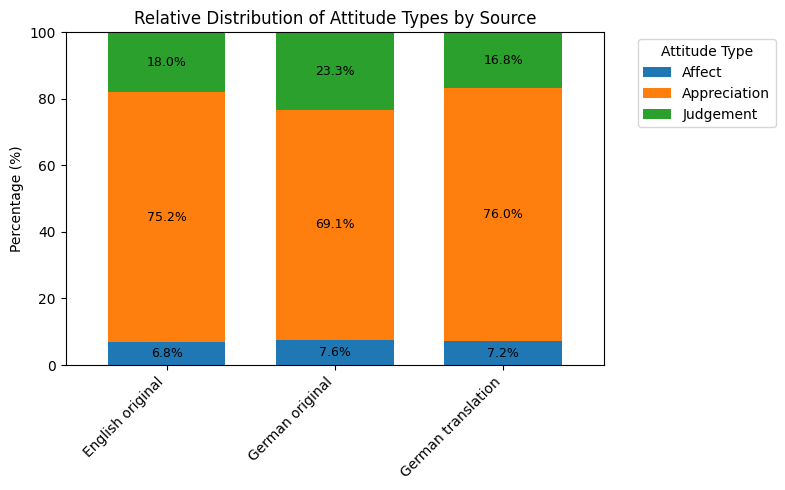

In [22]:
import matplotlib.pyplot as plt

# Percentage distribution of Attitude types per Source
attitude_by_source_pct = pd.crosstab(
    df_attitude["Source"],
    df_attitude["Attitude_type"],
    normalize="index"
).mul(100)

# Order categories
attitude_by_source_pct = attitude_by_source_pct[
    ["Affect", "Appreciation", "Judgement"]
]

print(attitude_by_source_pct.round(1))

# Plot 100% stacked bar chart
ax = attitude_by_source_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    width=0.7
)

plt.xlabel("")
plt.ylabel("Percentage (%)")
#plt.title("")

plt.xticks(rotation=45, ha="right")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" if v > 3 else "" for v in container.datavalues],
        label_type="center",
        fontsize=9
    )

plt.legend(
    title="Attitude Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Evaluative vs. non-evaluative, by Source

Are the three sources similarly evaluative overall?

Counts:
Evaluative_binary   Evaluative  Non-evaluative  nan  uncertain
Source                                                        
English original          1823             208    0          2
German original           1138              78   12          0
German translation        1295              73    0          2

Row percentages:
Evaluative_binary   Evaluative  Non-evaluative  nan  uncertain
Source                                                        
English original          89.7            10.2  0.0        0.1
German original           92.7             6.4  1.0        0.0
German translation        94.5             5.3  0.0        0.1
Evaluative use by Source: Chi2 = 66.72, df = 6, p = 0.0000, Cramér's V = 0.085 --> significant (p < .05)
   (caveat: smallest expected cell count is 1.1 -- below the usual rule-of-thumb of 5, so treat this test with caution)
Evaluative use by Source: Chi2 = 31.70, df = 2, p = 0.0000, Cramér's V = 0.083 --> significant (p < .05)


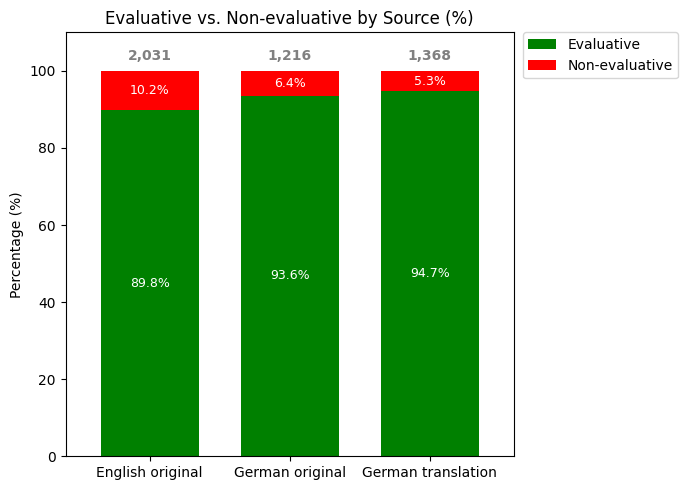

In [27]:
eval_by_source = pd.crosstab(df["Source"], df["Evaluative_binary"])
eval_by_source_pct = pd.crosstab(df["Source"], df["Evaluative_binary"], normalize="index").mul(100).round(1)

print("Counts:")
print(eval_by_source)
print()
print("Row percentages:")
print(eval_by_source_pct)

run_chi2(eval_by_source, "Evaluative use by Source: ")
import matplotlib.pyplot as plt

# Remove Uncertain / N-A
df_eval = df[df["Evaluative_binary"].isin(["Evaluative", "Non-evaluative"])].copy()

# Crosstab counts
eval_by_source = pd.crosstab(
    df_eval["Source"],
    df_eval["Evaluative_binary"]
)

# Percentage crosstab
eval_by_source_pct = pd.crosstab(
    df_eval["Source"],
    df_eval["Evaluative_binary"],
    normalize="index"
).mul(100).round(1)

# Ensure order
eval_by_source = eval_by_source[["Evaluative", "Non-evaluative"]]
eval_by_source_pct = eval_by_source_pct[["Evaluative", "Non-evaluative"]]


# Chi-square
run_chi2(eval_by_source, "Evaluative use by Source: ")

# Stacked percentage bar chart
ax = eval_by_source_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5),
    width=0.7,
    color=["green", "red"],

)

plt.title("Evaluative vs. Non-evaluative by Source (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("")
plt.xticks(rotation=0)

plt.ylim(0, 110)

# Add percentage labels inside bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" if v > 3 else "" for v in container.datavalues],
        label_type="center",
        fontsize=9,
        color = "white"
    )

# Add total N above bars
totals = eval_by_source.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        102,
        f"{total:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="gray"
    )

# Legend outside
legend_outside(ax)

plt.tight_layout()
plt.show()

## 6. Attitude type distribution, by Source (overall)

Across all 6 adjective concepts together, does the Attitude type distribution differ
between German originals, English originals, and German translations?

Counts:
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original       123          1362        325
German original         86           786        265
German translation      92           976        216

Row percentages:
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original       6.8          75.2       18.0
German original        7.6          69.1       23.3
German translation     7.2          76.0       16.8
Attitude type by Source: Chi2 = 20.61, df = 4, p = 0.0004, Cramér's V = 0.049 --> significant (p < .05)


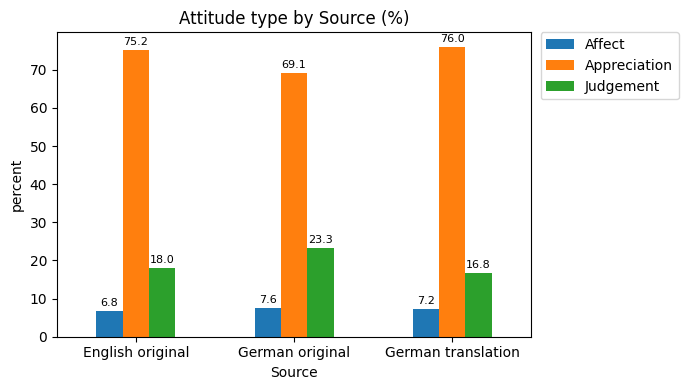

In [12]:
att_by_source = pd.crosstab(df_attitude["Source"], df_attitude["Attitude_type"])
att_by_source_pct = pd.crosstab(df_attitude["Source"], df_attitude["Attitude_type"], normalize="index").mul(100).round(1)

print("Counts:")
print(att_by_source)
print()
print("Row percentages:")
print(att_by_source_pct)

run_chi2(att_by_source, "Attitude type by Source: ")

ax = att_by_source_pct.plot(kind="bar")
label_bars(ax, fmt="%.1f")
legend_outside(ax)
plt.title("Attitude type by Source (%)")
plt.ylabel("percent")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Attitude type by Source — per adjective concept

Now we zoom in: for each of the 6 concepts individually (e.g. just *gut/good/gut*),
does the Attitude type distribution differ across the 3 sources? Small sample sizes per
concept mean some tests may be underpowered — read the Cramér's V alongside the p-value.

In [13]:
for concept in DE_TO_EN:
    sub = df_attitude[df_attitude["Concept_DE"] == concept]
    if sub.empty:
        print(f"--- {concept} / {DE_TO_EN[concept]}: no data yet ---\n")
        continue
    tab = pd.crosstab(sub["Source"], sub["Attitude_type"])
    print(f"--- {concept} / {DE_TO_EN[concept]} ---")
    print(tab)
    run_chi2(tab, "  ")
    print()


--- gut / good ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original        10           546        171
German original         33           372        168
German translation      11           463        142
  Chi2 = 36.91, df = 4, p = 0.0000, Cramér's V = 0.098 --> significant (p < .05)

--- wichtig / important ---
Attitude_type       Appreciation  Judgement
Source                                     
English original             242          6
German original              222         13
German translation           212          5
  Chi2 = 4.73, df = 2, p = 0.0939, Cramér's V = 0.082 --> not significant (p >= .05)

--- glücklich / happy ---
Attitude_type       Affect  Appreciation
Source                                  
English original       102            13
German original         30             0
German translation      76             7
  Chi2 = 3.82, df = 2, p = 0.1482, Cramér's V = 0.129 --> not significant 

## 8. Attitude type by Source — per Gender

Does the Source effect on Attitude type hold up separately for female and male
speakers?

In [14]:
for gender in sorted(df_attitude["Gender"].dropna().unique()):
    sub = df_attitude[df_attitude["Gender"] == gender]
    tab = pd.crosstab(sub["Source"], sub["Attitude_type"])
    print(f"--- Gender = {gender} ---")
    print(tab)
    run_chi2(tab, "  ")
    print()


--- Gender = F ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original        42           563        131
German original         55           370        120
German translation      32           392         91
  Chi2 = 16.65, df = 4, p = 0.0023, Cramér's V = 0.068 --> significant (p < .05)

--- Gender = M ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original        81           799        194
German original         31           416        145
German translation      60           584        125
  Chi2 = 18.17, df = 4, p = 0.0011, Cramér's V = 0.061 --> significant (p < .05)



## 9. Attitude type by Source — per Domain

Same check, per talk Domain. Domains with very little data will have unreliable tests
(flagged automatically by `run_chi2`).

In [15]:
for domain in sorted(df_attitude["Domain"].dropna().unique()):
    sub = df_attitude[df_attitude["Domain"] == domain]
    tab = pd.crosstab(sub["Source"], sub["Attitude_type"])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        print(f"--- Domain = {domain}: not enough variation to test ---\n")
        continue
    print(f"--- Domain = {domain} ---")
    print(tab)
    run_chi2(tab, "  ")
    print()


--- Domain = Art ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original         5            84         31
German original          5            91         23
German translation       3            55         23
  Chi2 = 2.52, df = 4, p = 0.6415, Cramér's V = 0.063 --> not significant (p >= .05)
   (caveat: smallest expected cell count is 3.3 -- below the usual rule-of-thumb of 5, so treat this test with caution)

--- Domain = Business ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original        27           137         26
German original          4            75         47
German translation      25           101         11
  Chi2 = 49.81, df = 4, p = 0.0000, Cramér's V = 0.234 --> significant (p < .05)

--- Domain = Education ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English origin

## 10. Depth analysis

The sections above give the overall picture. This section digs deeper into *why* and
*where* the sources differ.

**10.1 Pairwise Source comparisons** — the overall 3-way test tells us the three
sources aren't all alike, but not which pair(s) actually differ. We run the same test
on each pair separately.

**10.2 Standardized residuals** — for the overall Source x Attitude type table, which
specific cells (e.g. "German translation x Judgement") are pulling the Chi-square value
up? A standardized residual beyond ±2 is typically considered a notable contributor.

**10.3 Translation-shift analysis** — using the row-aligned data (same sentence, English
adjective vs. its German translation), we check directly: does the Attitude type stay
the same after translation, or does it shift? This is a more direct measure of
translation effects than comparing marginal distributions.

**10.4 Translation strategy and shift** — does whether the translator used an
"Equivalence" vs. an "Alteration" strategy relate to whether the Attitude type shifted?

In [16]:
# 10.1 Pairwise Source comparisons
sources = df_attitude["Source"].unique()
pairs = [(a, b) for i, a in enumerate(sources) for b in sources[i+1:]]

for a, b in pairs:
    sub = df_attitude[df_attitude["Source"].isin([a, b])]
    tab = pd.crosstab(sub["Source"], sub["Attitude_type"])
    print(f"--- {a}  vs.  {b} ---")
    print(tab)
    run_chi2(tab, "  ")
    print()


--- German original  vs.  English original ---
Attitude_type     Affect  Appreciation  Judgement
Source                                           
English original     123          1362        325
German original       86           786        265
  Chi2 = 14.16, df = 2, p = 0.0008, Cramér's V = 0.069 --> significant (p < .05)

--- German original  vs.  German translation ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
German original         86           786        265
German translation      92           976        216
  Chi2 = 16.82, df = 2, p = 0.0002, Cramér's V = 0.083 --> significant (p < .05)

--- English original  vs.  German translation ---
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original       123          1362        325
German translation      92           976        216
  Chi2 = 0.76, df = 2, p = 0.6847, Cramér's V = 0.016 --> not significant 

In [17]:
# 10.2 Standardized residuals for the overall Source x Attitude type table
chi2, p, dof, expected = chi2_contingency(att_by_source)
observed = att_by_source.values
residuals = (observed - expected) / np.sqrt(expected)

resid_df = pd.DataFrame(residuals, index=att_by_source.index, columns=att_by_source.columns).round(2)
print("Standardized residuals (values beyond +/-2 stand out):")
print(resid_df)


Standardized residuals (values beyond +/-2 stand out):
Attitude_type       Affect  Appreciation  Judgement
Source                                             
English original     -0.51          0.70      -1.07
German original       0.57         -1.85       3.29
German translation    0.07          0.91      -1.83


In [18]:
# 10.3 Translation-shift analysis: does the Attitude type stay the same after translation?
# This uses the ORIGINAL row-aligned pairs from each parallel file (not the filtered subset),
# so every English-original instance is compared to whatever it was actually translated as.
shift_rows = []
for adj, df_temp in en_de_dfs.items():
    tmp = pd.DataFrame({
        "Concept_EN": adj,
        "EN_Attitude_type": df_temp["EN_Attitude_type"].where(
            df_temp["EN_Attitude_type"].isna(), clean_text(df_temp["EN_Attitude_type"]).str.title()
        ),
        "DE_Attitude_type": df_temp["DE_Attitude_type"].where(
            df_temp["DE_Attitude_type"].isna(), clean_text(df_temp["DE_Attitude_type"]).str.title()
        ),
        "Translation_strategy": df_temp["Translation_strategy"],
    })
    shift_rows.append(tmp)

shift_df = pd.concat(shift_rows, ignore_index=True)
shift_df = shift_df[
    shift_df["EN_Attitude_type"].isin(VALID_ATTITUDE_TYPES) &
    shift_df["DE_Attitude_type"].isin(VALID_ATTITUDE_TYPES)
].copy()

shift_df["Shifted"] = shift_df["EN_Attitude_type"] != shift_df["DE_Attitude_type"]

print("Pairs with a valid Attitude type on both sides:", len(shift_df))
print(f"Attitude type changed during translation: {shift_df['Shifted'].mean()*100:.1f}%")
print()
print("Transition matrix (rows = English original, columns = German translation):")
transition = pd.crosstab(shift_df["EN_Attitude_type"], shift_df["DE_Attitude_type"])
print(transition)


Pairs with a valid Attitude type on both sides: 1721
Attitude type changed during translation: 0.8%

Transition matrix (rows = English original, columns = German translation):
DE_Attitude_type  Affect  Appreciation  Judgement
EN_Attitude_type                                 
Affect               117             0          0
Appreciation           2          1287          3
Judgement              0             8        304


In [19]:
# 10.4 Does translation strategy relate to whether the Attitude type shifted?
strategy_vs_shift = pd.crosstab(shift_df["Translation_strategy"], shift_df["Shifted"])
print(strategy_vs_shift)
run_chi2(strategy_vs_shift, "Translation strategy vs. Attitude shift: ")


Shifted               False  True 
Translation_strategy              
Alteration              103      2
Equivalence            1604     11
Translation strategy vs. Attitude shift: Chi2 = 0.67, df = 1, p = 0.4114, Cramér's V = 0.020 --> not significant (p >= .05)
   (caveat: smallest expected cell count is 0.8 -- below the usual rule-of-thumb of 5, so treat this test with caution)


(np.float64(0.6747490839401584),
 np.float64(0.4114007438332379),
 1,
 array([[1.04206395e+02, 7.93604651e-01],
        [1.60279360e+03, 1.22063953e+01]]))

## 11. Save results

Export the key tables to a single Excel file.

In [20]:
with pd.ExcelWriter("attitude_3way_comparison_results.xlsx") as writer:
    eval_by_source.to_excel(writer, sheet_name="evaluative_by_source")
    att_by_source.to_excel(writer, sheet_name="attitude_by_source")
    resid_df.to_excel(writer, sheet_name="standardized_residuals")
    transition.to_excel(writer, sheet_name="translation_shift_matrix")
    strategy_vs_shift.to_excel(writer, sheet_name="strategy_vs_shift")

print("Saved: attitude_3way_comparison_results.xlsx")


Saved: attitude_3way_comparison_results.xlsx
